In [1]:
from dotenv import load_dotenv

# Load OPENAI_API_KEY (and any other secrets) from a local .env file.
load_dotenv()


True

# Notebook 1 · Flat Multi-Agent System

> **Series:** LangChain MAS Architectures · Travel Agency Use Case

---

## Architecture Overview

In a **flat MAS** all agents are pure peers — there is no manager and no central
orchestrator. Every peer reads the *same* shared board and may challenge any
earlier decision. The system stops when all peers agree the plan is complete.

```
                      ┌──────────────────────────────┐
                      │       SHARED BOARD (state)   │
                      └──────────────────────────────┘
                              ▲ read / write ▼

START ──► destination_node ──► booking_node ──► experience_node
               ▲                                      │
               │         conditional edge             │
               └──── "another round needed" ──────────┤
                                                      │
                         "all ready or cap reached"   │
                                                      ▼
                                               summarizer_node ──► END
```

## Why LangGraph fits here

With **LangGraph** the looping logic lives in a **conditional edge** and the
stopping logic lives in an **edge function** — both are pure Python, not an LLM.
No agent decides when to call another agent.

## Pattern in this notebook

| LangGraph concept | Role in flat MAS |
|---|---|
| `TypedDict` state | `shared_board`, `ready` flags, `round_num` |
| `StateGraph` nodes | One node per peer + one summarizer node |
| `add_edge` | Fixed peer sequence within a round |
| `add_conditional_edges` | Peer-consensus check → loop or finish |
| `summarizer_node` | Final formatting (not a decision-maker) |


## 1 · Setup

In [2]:
# ── Traveler request ─────────────────────────────────────────────────────────
USER_REQUEST = """\
Plan a 4-day spring trip from Rome.
Requirements:
- mid-range budget
- easy flights
- central hotel
- mix of food and culture
- simple daily plan""".strip()

# ── Static catalog ────────────────────────────────────────────────────────────
DESTINATIONS = {
    "Lisbon":    {"best_period": "April-June", "style": "sunny, walkable, relaxed",
                  "notes": "great for food, viewpoints, and compact neighborhoods"},
    "Barcelona": {"best_period": "April-June", "style": "lively, artistic, seaside",
                  "notes": "strong mix of architecture, beach walks, and tapas"},
    "Prague":    {"best_period": "April-June", "style": "historic, compact, lower-cost",
                  "notes": "easy sightseeing with a classic old-town atmosphere"},
}

FLIGHTS = [
    {"destination": "Lisbon",    "code": "TP-833", "price": 180, "type": "direct",  "duration": "3h 05m"},
    {"destination": "Lisbon",    "code": "IB-310", "price": 150, "type": "1 stop",  "duration": "5h 10m"},
    {"destination": "Barcelona", "code": "VY-611", "price": 140, "type": "direct",  "duration": "1h 50m"},
    {"destination": "Barcelona", "code": "IB-220", "price": 125, "type": "1 stop",  "duration": "4h 00m"},
    {"destination": "Prague",    "code": "FR-721", "price": 110, "type": "direct",  "duration": "1h 55m"},
    {"destination": "Prague",    "code": "OS-410", "price": 145, "type": "1 stop",  "duration": "3h 45m"},
]

HOTELS = [
    {"destination": "Lisbon",    "name": "Baixa Stay",       "price_per_night": 145, "style": "central boutique hotel"},
    {"destination": "Lisbon",    "name": "River Rooms",       "price_per_night": 120, "style": "simple hotel near transit"},
    {"destination": "Barcelona", "name": "Born Hotel",        "price_per_night": 160, "style": "central design hotel"},
    {"destination": "Barcelona", "name": "Gracia Inn",        "price_per_night": 130, "style": "quiet hotel in a walkable district"},
    {"destination": "Prague",    "name": "Old Town House",    "price_per_night": 115, "style": "historic hotel near main sights"},
    {"destination": "Prague",    "name": "City Garden Hotel", "price_per_night":  95, "style": "budget-friendly hotel with tram access"},
]

ACTIVITIES = [
    {"destination": "Lisbon",    "name": "Alfama food walk",                    "tag": "food",    "price": 35},
    {"destination": "Lisbon",    "name": "Belem and river tram day",            "tag": "culture", "price": 25},
    {"destination": "Barcelona", "name": "Gothic Quarter tapas evening",        "tag": "food",    "price": 40},
    {"destination": "Barcelona", "name": "Sagrada Familia and modernism route", "tag": "culture", "price": 32},
    {"destination": "Prague",    "name": "Old Town walking tour",               "tag": "culture", "price": 18},
    {"destination": "Prague",    "name": "Czech dinner and jazz night",         "tag": "food",    "price": 30},
]

def flights_for(destination):    return [f for f in FLIGHTS    if f["destination"] == destination]
def hotels_for(destination):     return [h for h in HOTELS     if h["destination"] == destination]
def activities_for(destination): return [a for a in ACTIVITIES if a["destination"] == destination]

def catalog_text():
    lines = []
    for dest, info in DESTINATIONS.items():
        lines.append(f"Destination: {dest}")
        lines.append(f"  Best period : {info['best_period']}")
        lines.append(f"  Style       : {info['style']}")
        lines.append(f"  Notes       : {info['notes']}")
        lines.append("  Flights:")
        for f in flights_for(dest):
            lines.append(f"    - {f['code']} | {f['type']} | EUR {f['price']} | {f['duration']}")
        lines.append("  Hotels:")
        for h in hotels_for(dest):
            lines.append(f"    - {h['name']} | EUR {h['price_per_night']}/night | {h['style']}")
        lines.append("  Activities:")
        for a in activities_for(dest):
            lines.append(f"    - {a['name']} | {a['tag']} | EUR {a['price']}")
        lines.append("")
    return "\n".join(lines).strip()

CATALOG_TEXT = catalog_text()

print("USER_REQUEST:")
print(USER_REQUEST)
print("\nCatalog loaded - destinations:", list(DESTINATIONS.keys()))


USER_REQUEST:
Plan a 4-day spring trip from Rome.
Requirements:
- mid-range budget
- easy flights
- central hotel
- mix of food and culture
- simple daily plan

Catalog loaded - destinations: ['Lisbon', 'Barcelona', 'Prague']


## 2 · Graph State

We use a plain `TypedDict` — the idiomatic LangGraph state type — instead of
`AgentState`, because there is no `create_agent` wrapping the whole graph.

Key design choices:

| Field | Type | Why |
|---|---|---|
| `shared_board` | `Annotated[list[str], operator.add]` | `operator.add` is a **reducer**: LangGraph merges list returns by concatenation instead of overwrite |
| `round_num` | `int` | Incremented at the start of each round by `destination_node`; the edge function reads this to cap iterations |
| `dest_ready`, `booking_ready`, `exp_ready` | `bool` | Each peer node sets its own flag; the edge function reads all three |
| `final_itinerary` | `str` | Written only by `summarizer_node` |


In [3]:
import operator
from typing import Annotated
from typing_extensions import TypedDict

# The LangGraph state for the flat MAS.
# TypedDict (not AgentState) because the graph is built with StateGraph directly.
class FlatState(TypedDict):
    # shared_board uses operator.add as a reducer:
    # when a node returns {"shared_board": ["new entry"]}, LangGraph
    # *appends* it to the existing list rather than replacing the whole list.
    shared_board: Annotated[list[str], operator.add]

    # round_num is a plain int — the destination node increments it each round.
    round_num: int

    # Per-peer ready flags — each node sets its own, the edge reads all three.
    dest_ready:    bool
    booking_ready: bool
    exp_ready:     bool

    # Written only once, by the summarizer node at the very end.
    final_itinerary: str


## 3 · Peer Agents

Each peer is a `create_agent` instance with no tools — it only reasons and
produces a text contribution.

The system prompt encodes two things:
1. The **flat contract**: equal authority, may challenge any earlier idea.
2. A **readiness signal**: the peer ends its reply with `READY: YES` or `READY: NO`.

The readiness signal is parsed by the node function (not by another LLM).
This is the key difference from the previous design: the *decision* about
stopping is made by a plain Python edge function, not by a coordinator agent.


In [4]:
from langchain.agents import create_agent

_FLAT_CONTRACT = (
    "You are a peer agent in a flat travel-agency MAS. "
    "There is no manager - you have equal authority to every other peer. "
    "You MAY challenge or refine any earlier idea on the shared board. "
    "Only use options from the catalog. "
    "Reply with one concise contribution, then end your message on its own line with "
    "exactly 'READY: YES' if the plan covers destination, flight, hotel and activities "
    "well enough to present to the traveler, or 'READY: NO' if more work is needed."
)

destination_peer = create_agent(
    model="openai:gpt-4.1-mini",
    tools=[],
    system_prompt=(
        _FLAT_CONTRACT + "\n"
        "Your specialty: destination choice and best travel period."
    ),
)

booking_peer = create_agent(
    model="openai:gpt-4.1-mini",
    tools=[],
    system_prompt=(
        _FLAT_CONTRACT + "\n"
        "Your specialty: flight and hotel selection for budget and convenience."
    ),
)

experience_peer = create_agent(
    model="openai:gpt-4.1-mini",
    tools=[],
    system_prompt=(
        _FLAT_CONTRACT + "\n"
        "Your specialty: activity mix and overall trip coherence."
    ),
)

print("Peer agents defined.")


Peer agents defined.


## 4 · Node Functions

Each node is a plain **async Python function**.

The function:
1. Reads the current `shared_board` directly from `state`.
2. Invokes its peer agent with the board as context.
3. Parses the `READY:` line from the peer's response.
4. Returns a dict that LangGraph merges into the state.

> **No ToolRuntime, no Command, no coordinator.**
> The node function *is* the agent's turn. State flows directly through the graph.


In [5]:
import asyncio
from langchain.messages import HumanMessage

MAX_ROUNDS = 2  # safety cap — the conditional edge enforces this

# ── Helper: parse the READY signal from a peer's response ────────────────────
def _parse_ready(text: str) -> bool:
    for line in reversed(text.strip().splitlines()):
        upper = line.strip().upper()
        if "READY: YES" in upper:
            return True
        if "READY: NO" in upper:
            return False
    return False  # conservative default if the marker is missing

def _make_board_entry(peer_name: str, text: str, ready: bool, round_num: int) -> str:
    # Strip the READY line from the contribution text for board readability.
    contribution = "\n".join(
        line for line in text.splitlines()
        if "READY:" not in line.upper()
    ).strip()
    return f"[Round {round_num}] {peer_name} (ready={ready}):\n{contribution}"

# ── Node: destination_peer ────────────────────────────────────────────────────
# This is the FIRST node in each round, so it also increments round_num.
async def destination_node(state: FlatState) -> dict:
    print(f"--- destination_node (round {state['round_num'] + 1}) ---")

    board = state["shared_board"]
    board_text = "\n\n".join(board) if board else "Board is empty - first turn."
    round_num = state["round_num"] + 1  # increment at the start of each round

    response = await destination_peer.ainvoke({
        "messages": [HumanMessage(content=(
            f"Traveler request:\n{USER_REQUEST}\n\n"
            f"Catalog:\n{CATALOG_TEXT}\n\n"
            f"Shared board so far:\n{board_text}\n\n"
            "Add one concise contribution, then state READY: YES or READY: NO."
        ))]
    })
    text = response["messages"][-1].content
    ready = _parse_ready(text)
    entry = _make_board_entry("Destination peer", text, ready, round_num)

    # Return only the fields this node changes.
    # operator.add will append the entry to the existing shared_board list.
    return {
        "shared_board": [entry],
        "round_num":    round_num,
        "dest_ready":   ready,
    }

# ── Node: booking_peer ────────────────────────────────────────────────────────
async def booking_node(state: FlatState) -> dict:
    print(f"--- booking_node (round {state['round_num']}) ---")

    board_text = "\n\n".join(state["shared_board"])

    response = await booking_peer.ainvoke({
        "messages": [HumanMessage(content=(
            f"Traveler request:\n{USER_REQUEST}\n\n"
            f"Catalog:\n{CATALOG_TEXT}\n\n"
            f"Shared board so far:\n{board_text}\n\n"
            "Add one concise contribution, then state READY: YES or READY: NO."
        ))]
    })
    text = response["messages"][-1].content
    ready = _parse_ready(text)
    entry = _make_board_entry("Booking peer", text, ready, state['round_num'])

    return {
        "shared_board":  [entry],
        "booking_ready": ready,
    }

# ── Node: experience_peer ─────────────────────────────────────────────────────
# This is the LAST peer in each round — after it, the conditional edge fires.
async def experience_node(state: FlatState) -> dict:
    print(f"--- experience_node (round {state['round_num']}) ---")

    board_text = "\n\n".join(state["shared_board"])

    response = await experience_peer.ainvoke({
        "messages": [HumanMessage(content=(
            f"Traveler request:\n{USER_REQUEST}\n\n"
            f"Catalog:\n{CATALOG_TEXT}\n\n"
            f"Shared board so far:\n{board_text}\n\n"
            "Add one concise contribution, then state READY: YES or READY: NO."
        ))]
    })
    text = response["messages"][-1].content
    ready = _parse_ready(text)
    entry = _make_board_entry("Experience peer", text, ready, state['round_num'])

    return {
        "shared_board": [entry],
        "exp_ready":    ready,
    }

# ── Node: summarizer ──────────────────────────────────────────────────────────
# Pure formatting — no decisions. Reads the board and renders a clean itinerary.
# This replaces the coordinator's final summary without being a coordinator.
async def summarizer_node(state: FlatState) -> dict:
    print("--- summarizer_node ---")

    board_text = "\n\n".join(state["shared_board"])

    from langchain.chat_models import init_chat_model
    model = init_chat_model("openai:gpt-4.1-mini", temperature=0)

    from langchain.messages import SystemMessage
    result = await model.ainvoke([
        SystemMessage(content=(
            "You are a formatting assistant. "
            "Turn the shared travel board into one clean, client-ready itinerary. "
            "Do NOT change any decisions already made on the board. "
            "This is a pure formatting step."
        )),
        HumanMessage(content=(
            f"Traveler request:\n{USER_REQUEST}\n\n"
            f"Shared board (all peer contributions):\n{board_text}"
        )),
    ])
    return {"final_itinerary": result.content}

print("Node functions defined.")


Node functions defined.


## 5 · The Conditional Edge — Peer Consensus Without a Coordinator

**A plain Python function** makes that decision by reading the state directly.

```
experience_node ──► route_after_experience ──► "destination_node"  (loop)
                                           └──► "summarizer"       (stop)
```

### Routing logic

| Condition | Next node |
|---|---|
| All three `*_ready` flags are `True` | `"summarizer"` — peers agreed |
| `round_num >= MAX_ROUNDS` | `"summarizer"` — safety cap reached |
| Otherwise | `"destination_node"` — start another round |

This logic is architectural (an edge), not agential (an LLM call).


In [6]:
from typing import Literal

def route_after_experience(state: FlatState) -> Literal["destination_node", "summarizer"]:
    # Check whether every peer voted ready in the most recent round.
    all_ready = (
        state["dest_ready"] and
        state["booking_ready"] and
        state["exp_ready"]
    )

    if all_ready:
        print(f"  [edge] All peers ready after round {state['round_num']} -> summarizer")
        return "summarizer"

    if state["round_num"] >= MAX_ROUNDS:
        print(f"  [edge] Safety cap reached ({MAX_ROUNDS} rounds) -> summarizer")
        return "summarizer"

    print(f"  [edge] Not all peers ready -> another round (round {state['round_num'] + 1})")
    return "destination_node"


## 6 · Build the Graph

Now we wire nodes and edges together using `StateGraph`.

The full graph topology:
```
START
  └──► destination_node
             └──► booking_node
                       └──► experience_node
                                 └──► [route_after_experience]
                                            ├──► destination_node  (loop back)
                                            └──► summarizer
                                                     └──► END
```


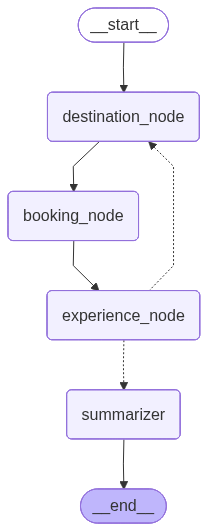

In [7]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# Initialise the graph with our state schema
builder = StateGraph(FlatState)

# ── Register nodes ────────────────────────────────────────────────────────────
builder.add_node("destination_node", destination_node)
builder.add_node("booking_node",     booking_node)
builder.add_node("experience_node",  experience_node)
builder.add_node("summarizer",       summarizer_node)

# ── Fixed edges within a round ────────────────────────────────────────────────
# The peer sequence is always: destination -> booking -> experience.
# This is the flat-MAS contract encoded in graph structure, not in a prompt.
builder.add_edge(START,               "destination_node")
builder.add_edge("destination_node",  "booking_node")
builder.add_edge("booking_node",      "experience_node")

# ── Conditional edge after the last peer in each round ───────────────────────
# route_after_experience reads the ready flags and round_num from state
# and returns the name of the next node — no LLM involved.
builder.add_conditional_edges(
    "experience_node",         # source node
    route_after_experience,    # routing function (pure Python)
    {
        "destination_node": "destination_node",  # loop: start another round
        "summarizer":       "summarizer",         # stop: go to final formatting
    }
)

# ── Terminal edge ─────────────────────────────────────────────────────────────
builder.add_edge("summarizer", END)

# ── Compile ───────────────────────────────────────────────────────────────────
graph = builder.compile()

# Visualise the graph — the loop back to destination_node is clearly visible
display(Image(graph.get_graph().draw_mermaid_png()))


## 7 · Run

The graph is invoked with an initial state dict.
`shared_board` is seeded with one kickoff entry so all peers have a starting
context even on the very first turn.

All other fields start at their zero values (`round_num=0`, flags `False`,
`final_itinerary=""`).


In [8]:
initial_state = {
    # Kickoff entry so every peer has a non-empty board on turn 1.
    "shared_board":  ["Kickoff: plan a trip that satisfies the traveler request."],
    "round_num":     0,
    "dest_ready":    False,
    "booking_ready": False,
    "exp_ready":     False,
    "final_itinerary": "",
}

# graph.invoke() is synchronous — use ainvoke() in a true async context.
# In Jupyter notebooks, top-level await works in newer kernels.
result = await graph.ainvoke(initial_state)


--- destination_node (round 1) ---
--- booking_node (round 1) ---
--- experience_node (round 1) ---
  [edge] Not all peers ready -> another round (round 2)
--- destination_node (round 2) ---
--- booking_node (round 2) ---
--- experience_node (round 2) ---
  [edge] All peers ready after round 2 -> summarizer
--- summarizer_node ---


In [9]:
from pprint import pprint

# Full state after the graph has finished
pprint(result)


{'booking_ready': True,
 'dest_ready': True,
 'exp_ready': True,
 'final_itinerary': '**4-Day Spring Trip Itinerary from Rome to Lisbon**\n'
                    '\n'
                    '---\n'
                    '\n'
                    '### Overview\n'
                    '- **Destination:** Lisbon, Portugal  \n'
                    '- **Trip Duration:** 4 days  \n'
                    '- **Budget:** Mid-range  \n'
                    '- **Focus:** Mix of food and culture with simple daily '
                    'plans  \n'
                    '- **Accommodation:** Central hotel in Lisbon  \n'
                    '- **Flight:** Direct flight from Rome to Lisbon  \n'
                    '\n'
                    '---\n'
                    '\n'
                    '### Travel Details\n'
                    '\n'
                    '- **Flight:**  \n'
                    '  - Airline: TAP Air Portugal (Flight TP-833)  \n'
                    '  - Duration: 3h 05m  \n'
                  

In [10]:
# The shared board — every peer contribution from every round
print("=" * 60)
print("SHARED BOARD")
print("=" * 60)
for entry in result["shared_board"]:
    print("\n" + entry)


SHARED BOARD

Kickoff: plan a trip that satisfies the traveler request.

[Round 1] Destination peer (ready=True):
Lisbon suits well for a 4-day spring trip from Rome with direct flights (TP-833, EUR 180, 3h 05m) and a charming, central hotel option like Baixa Stay (EUR 145/night). It offers a great blend of food and culture with activities like the Alfama food walk (EUR 35) and Belem and river tram day (EUR 25). Its sunny, walkable style fits a relaxed, simple daily plan.

[Round 1] Booking peer (ready=False):
For budget-friendliness and convenience, consider Prague as an alternative: direct flight FR-721 at EUR 110 and 1h 55m flight time, plus Old Town House hotel at EUR 115/night centrally located near sights. Activities like the Old Town walking tour (EUR 18) and Czech dinner with jazz (EUR 30) offer a classic cultural and food mix with an easy, compact itinerary.

[Round 1] Experience peer (ready=True):
To optimize the activity mix and coherence, I suggest focusing on Lisbon becaus

In [11]:
# The final itinerary produced by the summarizer node
print("=" * 60)
print("FINAL ITINERARY")
print("=" * 60)
print(result["final_itinerary"])


FINAL ITINERARY
**4-Day Spring Trip Itinerary from Rome to Lisbon**

---

### Overview
- **Destination:** Lisbon, Portugal  
- **Trip Duration:** 4 days  
- **Budget:** Mid-range  
- **Focus:** Mix of food and culture with simple daily plans  
- **Accommodation:** Central hotel in Lisbon  
- **Flight:** Direct flight from Rome to Lisbon  

---

### Travel Details

- **Flight:**  
  - Airline: TAP Air Portugal (Flight TP-833)  
  - Duration: 3h 05m  
  - Cost: Approx. EUR 180 (one-way)  
  - Notes: Direct flight for convenience and ease  

- **Hotel:**  
  - Name: Baixa Stay  
  - Location: Central Lisbon (near Rossio Square)  
  - Cost: Approx. EUR 145 per night  
  - Features: Charming, centrally located for easy access to main sights  

---

### Daily Itinerary

**Day 1: Arrival and Orientation**  
- Arrive in Lisbon and check in at Baixa Stay  
- Light evening stroll around Rossio Square and nearby areas to get acquainted with the city atmosphere  

**Day 2: Alfama Food Walk & Leisu

## 8 · Key Takeaways

| What you saw | Why it matters |
|---|---|
| `StateGraph` nodes as peer agents | Each peer *is* a graph node — no coordinator wraps them |
| `Annotated[list[str], operator.add]` | LangGraph reducer accumulates board entries across nodes |
| `route_after_experience` (pure Python) | The consensus check is structural code, not an LLM decision |
| `add_conditional_edges` loop | The cycling-back-when-not-ready is an architectural edge, not a prompt |
| `summarizer_node` | Pure formatting at the end — never makes planning decisions |

### Contrast with the previous version

| Aspect | Previous (coordinator) | This version (LangGraph) |
|---|---|---|
| Looping | `create_agent` coordinator called tools in a loop | `conditional_edge` loops back to `destination_node` |
| Stopping | Coordinator LLM read READY signals | Pure Python edge function reads state flags |
| Summarising | Coordinator LLM wrote the final summary | Dedicated `summarizer_node` (non-agent) |
| Authority | Coordinator *could* override peers | No agent has authority — the graph structure does |
